# 04 -- Feature Extraction

All features are dimensionless (scale-invariant or baseline-deviation), so an
operating-point difference between runs cannot be mistaken for a fault. No
feature *selection* happens here -- that stays inside each CV fold in
notebook 05 to avoid selection leakage. The only pruning done here is a
**low-variance filter**: features that are almost constant across every
window carry no class information, by definition, regardless of dataset --
so this is a documented floor (`P.LOW_VAR_THRESH`), not a tuned cut.

In [2]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
%matplotlib inline
import pdm_common as P

from pathlib import Path
P.RAW_DIR = Path(r"E:\DRDO\Sarthak Dhaigude_DRDO\PdM-main\RAW_DIR\raw")

import json, numpy as np, pandas as pd

In [3]:
clean = pd.read_parquet(P.ART_DIR / "clean_runs.parquet")
common = json.loads((P.ART_DIR / "common_signals.json").read_text())

parts = []
for rid, g in clean.groupby("run_id"):
    g = g.sort_values("time").reset_index(drop=True)
    feats = P.build_run_features(g[["time"] + common], g["label"].iloc[0], rid,
                                 bool(g["always_on"].iloc[0]), common)
    if not feats.empty:
        parts.append(feats)

features = pd.concat(parts, ignore_index=True)
num = features.select_dtypes(float)
features[num.columns] = num.replace([np.inf, -np.inf], np.nan).fillna(0.0)

feat_cols = [c for c in features.columns if c not in ("run_id", "label", "t_start")]
kept, dropped_lowvar = P.low_variance_filter(features, feat_cols)
print("No low-variance features found." if not dropped_lowvar
      else f"Dropped {len(dropped_lowvar)} low-variance feature(s): {dropped_lowvar}")

features = features[["run_id", "label", "t_start"] + kept]
features.to_parquet(P.ART_DIR / "features.parquet")
features.to_csv(P.ART_DIR / "features.csv", index=False)
feat_cols = kept

No low-variance features found.


## Summary statistics

In [4]:
summary = pd.DataFrame([
    ("windows (rows)", features.shape[0]),
    ("features extracted (pre low-var filter)", features.shape[0] and len(feat_cols) + len(dropped_lowvar)),
    ("features dropped (low variance)", len(dropped_lowvar)),
    ("features remaining", len(feat_cols)),
    ("classes", features["label"].nunique()),
    ("runs", features["run_id"].nunique()),
], columns=["metric", "value"])
summary

,metric,value
0,windows (rows),267
1,features extracted (pre low-var filter),51
2,features dropped (low variance),0
3,features remaining,51
4,classes,5
5,runs,13


## Windows per class / per run

In [5]:
display(features["label"].value_counts().rename("windows"))
display(features.groupby("run_id")["label"].agg(["first", "size"]).rename(
    columns={"first": "label", "size": "windows"}))

label
PumpDisplacement    96
GeneratorFault      82
Leakage             43
FlexibleShaft       37
Healthy              9
Name: windows, dtype: int64

,label,windows
run_id,,
Healthy Data 3,Healthy,9
Leakage_factor,Leakage,9
Medium_FlexibleShaft_Fault,FlexibleShaft,19
MildFlexible_shaft,FlexibleShaft,18
disp1_fault(0.5),PumpDisplacement,19
disp2_fault(0.3),PumpDisplacement,19
disp3_fault(0.2),PumpDisplacement,19
leakage_fault(0.5),Leakage,17
leakage_fault(1.0),Leakage,17


## Feature correlation heatmap (EDA only -- no features removed on this basis, per project decision: only remove if evidence of many |r| > 0.95 pairs)

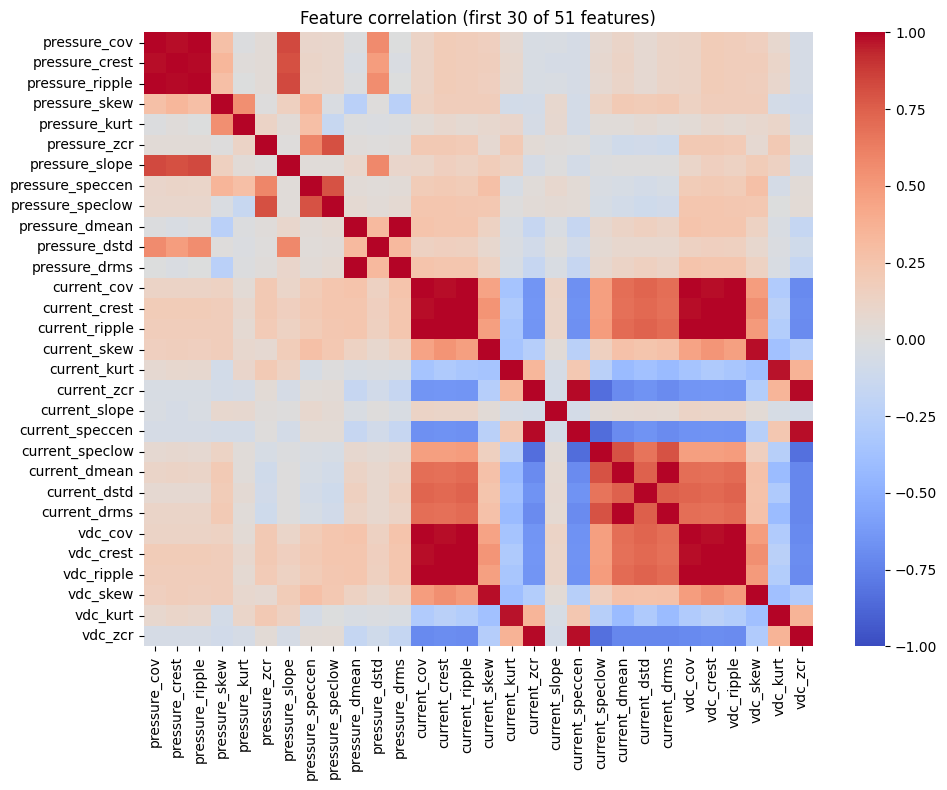

25 feature pair(s) with |r| > 0.95 -- consider pruning:


current_cov      vdc_cov            0.999988
current_ripple   vdc_ripple         0.999963
current_crest    vdc_crest          0.999959
pressure_dmean   pressure_drms      0.999943
current_dmean    current_drms       0.999935
pressure_cov     pressure_ripple    0.998335
current_ripple   vdc_cov            0.994776
vdc_cov          vdc_ripple         0.994757
current_cov      current_ripple     0.994756
                 vdc_ripple         0.994695
current_ripple   vdc_crest          0.993424
vdc_crest        vdc_ripple         0.993381
current_crest    current_ripple     0.993343
                 vdc_ripple         0.993223
current_zcr      vdc_zcr            0.988696
                 current_speccen    0.987132
pressure_crest   pressure_ripple    0.986223
vdc_cov          vdc_crest          0.983808
current_cov      vdc_crest          0.983785
                 current_crest      0.983713
current_crest    vdc_cov            0.983693
current_skew     vdc_skew           0.979302
pressure_c

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
show_cols = feat_cols[:30]  # cap for readability
corr = features[show_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, ax=ax,
           xticklabels=True, yticklabels=True)
ax.set_title(f"Feature correlation (first {len(show_cols)} of {len(feat_cols)} features)")
plt.tight_layout(); plt.show()

high = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
high = high[high.abs() > 0.95]
print("No feature pairs with |r| > 0.95." if high.empty
      else f"{len(high)} feature pair(s) with |r| > 0.95 -- consider pruning:")
if not high.empty:
    display(high.sort_values(key=abs, ascending=False))

## Per-class mean of a few invariant features (sanity check: should differ by FAULT, not by run scale)

In [7]:
show = [c for c in ["pressure_cov", "vdc_dmean", "power_cov", "corr_vdc_i"] if c in feat_cols]
features.groupby("label")[show].mean().round(3)

,pressure_cov,vdc_dmean,power_cov,corr_vdc_i
label,,,,
FlexibleShaft,0.040,-0.000,0.224,1.000
GeneratorFault,0.052,-0.048,0.309,1.000
Healthy,0.000,0.030,0.085,1.000
Leakage,0.013,-1.645,0.003,0.807
PumpDisplacement,0.047,-0.022,0.362,1.000
